## 1. Import Library & Konfigurasi

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings('ignore')

# Palet warna
BLUE   = '#2563EB'
GREEN  = '#16A34A'
RED    = '#DC2626'
AMBER  = '#D97706'
PURPLE = '#7C3AED'
GRAY   = '#6B7280'
LIGHT  = '#F8FAFC'

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.facecolor'   : LIGHT,
    'figure.facecolor' : 'white',
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'grid.color'       : '#CBD5E1'
})

print('Library berhasil diimport.')

Library berhasil diimport.


---
## 2. Load Dataset & Inspeksi Awal

In [5]:
df = pd.read_csv('hotel_bookings.csv')

print(f'Jumlah baris  : {len(df):,}')
print(f'Jumlah kolom  : {len(df.columns)}')
print(f'\nTipe data:')
print(df.dtypes)

Jumlah baris  : 119,390
Jumlah kolom  : 32

Tipe data:
hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type         

In [6]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [7]:
df.describe().round(2)

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119390.00,119386.0,119390.00,119390.00,119390.00,119390.00,119390.00,103050.00,6797.00,119390.00,119390.00,119390.00,119390.00
mean,0.37,104.01,2016.16,27.17,15.80,0.93,2.50,1.86,0.1,0.01,0.03,0.09,0.14,0.22,86.69,189.27,2.32,101.83,0.06,0.57
std,0.48,106.86,0.71,13.61,8.78,1.00,1.91,0.58,0.4,0.10,0.18,0.84,1.50,0.65,110.77,131.66,17.59,50.54,0.25,0.79
min,0.00,0.00,2015.00,1.00,1.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,1.00,6.00,0.00,-6.38,0.00,0.00
25%,0.00,18.00,2016.00,16.00,8.00,0.00,1.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,9.00,62.00,0.00,69.29,0.00,0.00
50%,0.00,69.00,2016.00,28.00,16.00,1.00,2.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,14.00,179.00,0.00,94.58,0.00,0.00
75%,1.00,160.00,2017.00,38.00,23.00,2.00,3.00,2.00,0.0,0.00,0.00,0.00,0.00,0.00,229.00,270.00,0.00,126.00,0.00,1.00
max,1.00,737.00,2017.00,53.00,31.00,19.00,50.00,55.00,10.0,10.00,1.00,26.00,72.00,21.00,535.00,543.00,391.00,5400.00,8.00,5.00


---
## 3. EDA untuk Anomaly Detection

### Identifikasi Kandidat Anomali

In [8]:
print('=== KANDIDAT ANOMALI DI DATASET ===')
print(f'ADR negatif (tidak logis)     : {(df["adr"] < 0).sum()} baris')
print(f'ADR > 1000 EUR (ekstrem)      : {(df["adr"] > 1000).sum()} baris')
print(f'adults = 0 (tanpa tamu dewasa): {(df["adults"] == 0).sum()} baris')
print(f'lead_time > 500 hari          : {(df["lead_time"] > 500).sum()} baris')
print(f'stays_in_week_nights > 30     : {(df["stays_in_week_nights"] > 30).sum()} baris')
print(f'stays_in_weekend_nights > 10  : {(df["stays_in_weekend_nights"] > 10).sum()} baris')
print(f'booking_changes > 10          : {(df["booking_changes"] > 10).sum()} baris')
print(f'previous_cancellations > 10   : {(df["previous_cancellations"] > 10).sum()} baris')

=== KANDIDAT ANOMALI DI DATASET ===
ADR negatif (tidak logis)     : 1 baris
ADR > 1000 EUR (ekstrem)      : 1 baris
adults = 0 (tanpa tamu dewasa): 403 baris
lead_time > 500 hari          : 481 baris
stays_in_week_nights > 30     : 9 baris
stays_in_weekend_nights > 10  : 15 baris
booking_changes > 10          : 24 baris
previous_cancellations > 10   : 180 baris


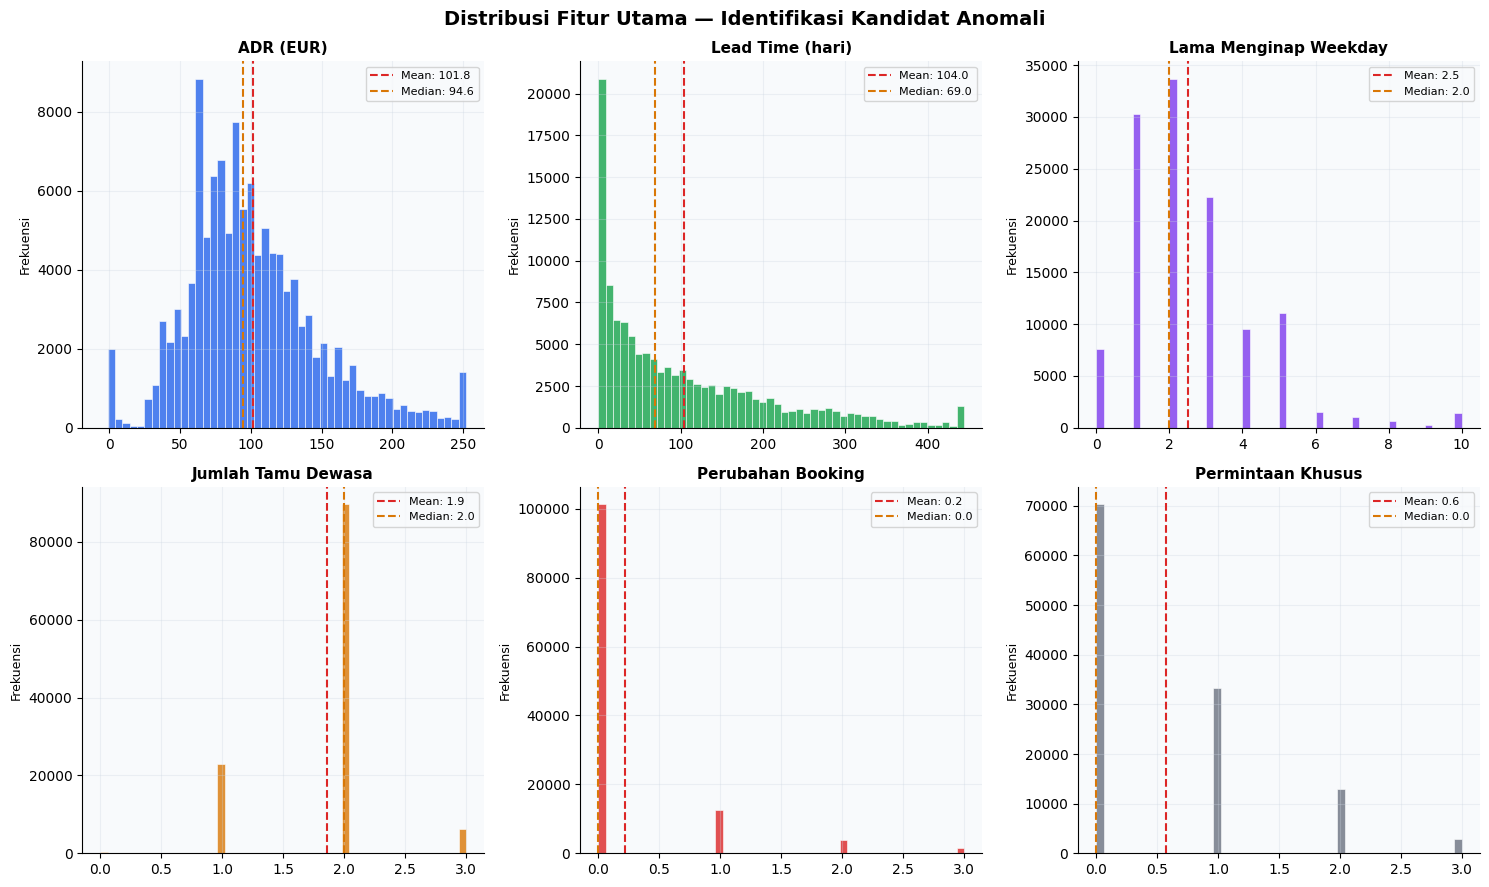

Gambar disimpan: eda_distribusi_fitur.png


In [9]:
# Visualisasi distribusi fitur kandidat anomali
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Distribusi Fitur Utama — Identifikasi Kandidat Anomali',
             fontsize=14, fontweight='bold')

features = [
    ('adr',                    'ADR (EUR)',            BLUE),
    ('lead_time',              'Lead Time (hari)',     GREEN),
    ('stays_in_week_nights',   'Lama Menginap Weekday', PURPLE),
    ('adults',                 'Jumlah Tamu Dewasa',   AMBER),
    ('booking_changes',        'Perubahan Booking',    RED),
    ('total_of_special_requests', 'Permintaan Khusus', GRAY),
]

for ax, (col, label, color) in zip(axes.flatten(), features):
    data = df[col].clip(upper=df[col].quantile(0.99))  # clip untuk visualisasi
    ax.hist(data, bins=50, color=color, alpha=0.8, edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].mean(),   color=RED,   linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color=AMBER, linestyle='--', linewidth=1.5,
               label=f'Median: {df[col].median():.1f}')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Frekuensi', fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('eda_distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: eda_distribusi_fitur.png')

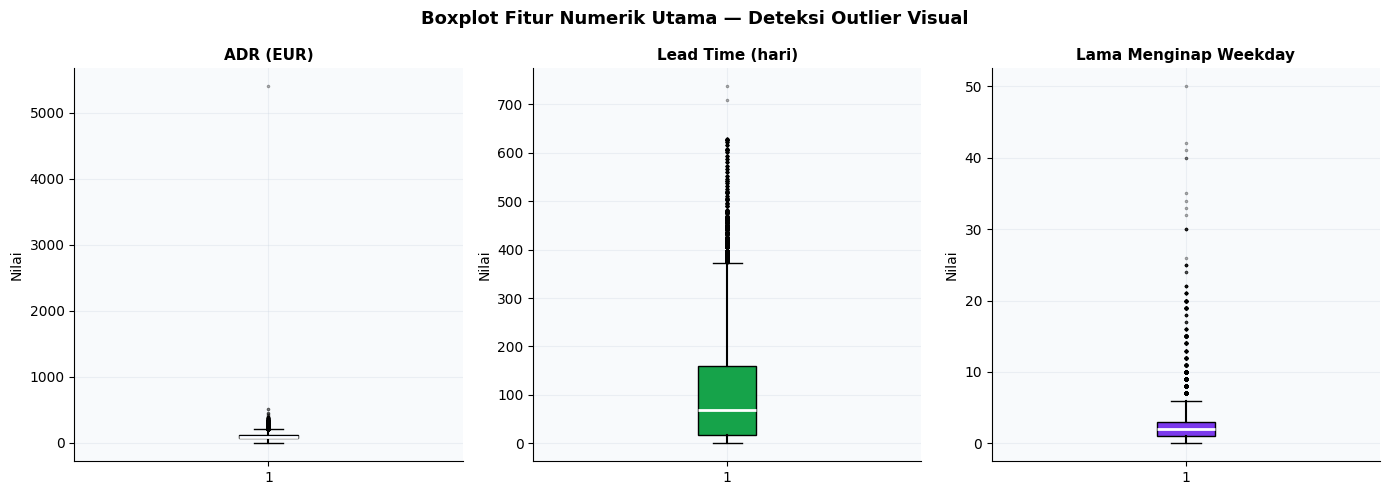

Gambar disimpan: eda_boxplot_outlier.png


In [10]:
# Boxplot untuk deteksi outlier secara visual
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Boxplot Fitur Numerik Utama — Deteksi Outlier Visual',
             fontsize=13, fontweight='bold')

for ax, (col, label, color) in zip(axes, features[:3]):
    bp = ax.boxplot(df[col].dropna(), patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    flierprops=dict(marker='.', markersize=3, alpha=0.4, color=RED))
    bp['boxes'][0].set_facecolor(color)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Nilai', fontsize=10)

plt.tight_layout()
plt.savefig('eda_boxplot_outlier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: eda_boxplot_outlier.png')

### Missing Values

In [11]:
mv     = df.isnull().sum()
mv     = mv[mv > 0].sort_values(ascending=False)
mv_pct = (mv / len(df) * 100).round(2)

mv_df = pd.DataFrame({
    'Jumlah Missing' : mv.values,
    'Persentase (%)'  : mv_pct.values,
    'Strategi'        : [
        'DROP kolom — 94.3% kosong, tidak informatif',
        'Imputasi dengan "Unknown" — booking tanpa agen tetap valid',
        'Imputasi dengan modus ("PRT") — mayoritas tamu dari Portugal',
        'Imputasi dengan 0 — asumsi tidak ada anak'
    ]
}, index=mv.index)

print('Missing Values per Kolom:')
print(mv_df.to_string())

Missing Values per Kolom:
          Jumlah Missing  Persentase (%)                                                      Strategi
company           112593           94.31                   DROP kolom — 94.3% kosong, tidak informatif
agent              16340           13.69    Imputasi dengan "Unknown" — booking tanpa agen tetap valid
country              488            0.41  Imputasi dengan modus ("PRT") — mayoritas tamu dari Portugal
children               4            0.00                     Imputasi dengan 0 — asumsi tidak ada anak


---
## 4. Data Preprocessing Pipeline

### Step 1 — Data Cleaning

In [12]:
df_clean = df.copy()
print(f'Shape awal: {df_clean.shape}')

# --- Drop kolom tidak berguna / data leakage ---
cols_to_drop = [
    'company',                  # 94.3% missing
    'reservation_status',       # data leakage — diketahui setelah booking selesai
    'reservation_status_date',  # data leakage
    'arrival_date_year',        # tidak relevan untuk deteksi anomali pola
    'arrival_date_week_number', # redundan dengan bulan
    'arrival_date_day_of_month',# terlalu granular
]
df_clean.drop(columns=cols_to_drop, inplace=True)
print(f'Setelah drop kolom: {df_clean.shape}')

# --- Hapus duplikat ---
n_dup = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
print(f'Baris duplikat dihapus: {n_dup}')

print(f'\nShape setelah cleaning: {df_clean.shape}')

Shape awal: (119390, 32)
Setelah drop kolom: (119390, 26)
Baris duplikat dihapus: 32468

Shape setelah cleaning: (86922, 26)


### Step 2 — Handling Missing Values

In [13]:
# Imputasi agent → 'Unknown'
df_clean['agent'] = df_clean['agent'].fillna('Unknown').astype(str)

# Imputasi country → modus
country_mode = df_clean['country'].mode()[0]
df_clean['country'] = df_clean['country'].fillna(country_mode)

# Imputasi children → 0
df_clean['children'] = df_clean['children'].fillna(0).astype(int)

# Verifikasi
remaining_mv = df_clean.isnull().sum()
print('Missing values setelah imputasi:')
print(remaining_mv[remaining_mv > 0] if remaining_mv.sum() > 0 else '  Tidak ada missing value tersisa ✓')

Missing values setelah imputasi:
  Tidak ada missing value tersisa ✓


### Step 3 — Feature Engineering

In [14]:
# total_nights: total durasi menginap
df_clean['total_nights'] = (
    df_clean['stays_in_week_nights'] + df_clean['stays_in_weekend_nights']
)

# total_guests: total jumlah tamu
df_clean['total_guests'] = (
    df_clean['adults'] + df_clean['children'] + df_clean['babies']
)

# room_mismatch: 1 jika kamar yang diberikan berbeda dari yang dipesan
df_clean['room_mismatch'] = (
    df_clean['reserved_room_type'] != df_clean['assigned_room_type']
).astype(int)

# arrival_season: musim kedatangan
season_map = {
    'December': 'Winter', 'January': 'Winter',  'February': 'Winter',
    'March'   : 'Spring', 'April'  : 'Spring',  'May'     : 'Spring',
    'June'    : 'Summer', 'July'   : 'Summer',  'August'  : 'Summer',
    'September':'Fall',   'October': 'Fall',    'November': 'Fall'
}
df_clean['arrival_season'] = df_clean['arrival_date_month'].map(season_map)

# adr_per_night: ADR relatif terhadap durasi (deteksi harga aneh)
df_clean['adr_per_guest'] = df_clean.apply(
    lambda r: r['adr'] / r['total_guests'] if r['total_guests'] > 0 else 0, axis=1
)

print('Fitur baru yang dibuat:')
new_features = ['total_nights','total_guests','room_mismatch','arrival_season','adr_per_guest']
print(df_clean[new_features].describe().round(2))

Fitur baru yang dibuat:
       total_nights  total_guests  room_mismatch  adr_per_guest
count      86922.00      86922.00       86922.00       86922.00
mean           3.64          2.03           0.15          55.52
std            2.76          0.80           0.36          29.84
min            0.00          0.00           0.00          -3.19
25%            2.00          2.00           0.00          37.83
50%            3.00          2.00           0.00          50.00
75%            5.00          2.00           0.00          67.42
max           69.00         55.00           1.00        2700.00


### Step 4 — Feature Selection

In [15]:
# Fitur numerik yang digunakan
numerical_features = [
    'lead_time',                   # jarak pemesanan — anomali jika terlalu ekstrem
    'adr',                         # harga kamar — anomali jika negatif atau ekstrem tinggi
    'total_nights',                # durasi menginap — anomali jika sangat panjang
    'total_guests',                # jumlah tamu — anomali jika 0
    'adr_per_guest',               # harga per tamu — deteksi kombinasi aneh
    'total_of_special_requests',   # permintaan khusus
    'booking_changes',             # perubahan booking — anomali jika sangat banyak
    'previous_cancellations',      # riwayat batal
    'days_in_waiting_list',        # lama tunggu
    'required_car_parking_spaces', # kebutuhan parkir
    'is_repeated_guest',           # tamu lama
    'room_mismatch',               # ketidakcocokan kamar
]

# Fitur kategorikal yang digunakan
categorical_features = [
    'hotel',
    'market_segment',
    'deposit_type',
    'customer_type',
    'meal',
    'arrival_season',
]

# Fitur yang di-drop 
dropped_features = {
    'is_canceled'              : 'Bukan fitur pola booking — label hasil akhir',
    'agent'                    : 'Kardinalitas terlalu tinggi setelah imputasi',
    'country'                  : 'Kardinalitas sangat tinggi (177 negara)',
    'stays_in_week_nights'     : 'Sudah terwakili oleh total_nights',
    'stays_in_weekend_nights'  : 'Sudah terwakili oleh total_nights',
    'adults'                   : 'Sudah terwakili oleh total_guests',
    'children'                 : 'Sudah terwakili oleh total_guests',
    'babies'                   : 'Sudah terwakili oleh total_guests',
    'reserved_room_type'       : 'Sudah diwakili room_mismatch',
    'assigned_room_type'       : 'Sudah diwakili room_mismatch',
    'distribution_channel'     : 'Berkorelasi tinggi dengan market_segment',
    'arrival_date_month'       : 'Sudah diwakili arrival_season',
    'previous_bookings_not_canceled': 'Korelasi rendah dengan pola anomali',
}

print(f'Fitur numerik  : {len(numerical_features)}')
print(f'Fitur kategorikal: {len(categorical_features)}')
print(f'Fitur di-drop  : {len(dropped_features)}')
print(f'\nFitur yang di-drop:')
for k, v in dropped_features.items():
    print(f'  {k:40s} → {v}')

Fitur numerik  : 12
Fitur kategorikal: 6
Fitur di-drop  : 13

Fitur yang di-drop:
  is_canceled                              → Bukan fitur pola booking — label hasil akhir
  agent                                    → Kardinalitas terlalu tinggi setelah imputasi
  country                                  → Kardinalitas sangat tinggi (177 negara)
  stays_in_week_nights                     → Sudah terwakili oleh total_nights
  stays_in_weekend_nights                  → Sudah terwakili oleh total_nights
  adults                                   → Sudah terwakili oleh total_guests
  children                                 → Sudah terwakili oleh total_guests
  babies                                   → Sudah terwakili oleh total_guests
  reserved_room_type                       → Sudah diwakili room_mismatch
  assigned_room_type                       → Sudah diwakili room_mismatch
  distribution_channel                     → Berkorelasi tinggi dengan market_segment
  arrival_date_month    

### Step 5 — Encoding Fitur Kategorikal

In [17]:
df_model = df_clean[numerical_features + categorical_features].copy()
print(f'Shape sebelum encoding: {df_model.shape}')

# One-Hot Encoding untuk fitur kategorikal
# drop_first=True untuk menghindari multikolinearitas (dummy variable trap)
df_encoded = pd.get_dummies(df_model, columns=categorical_features, drop_first=True)

print(f'Shape setelah One-Hot Encoding: {df_encoded.shape}')
print(f'\nDaftar kolom setelah encoding:')
print(list(df_encoded.columns))

Shape sebelum encoding: (86922, 18)
Shape setelah One-Hot Encoding: (86922, 32)

Daftar kolom setelah encoding:
['lead_time', 'adr', 'total_nights', 'total_guests', 'adr_per_guest', 'total_of_special_requests', 'booking_changes', 'previous_cancellations', 'days_in_waiting_list', 'required_car_parking_spaces', 'is_repeated_guest', 'room_mismatch', 'hotel_Resort Hotel', 'market_segment_Complementary', 'market_segment_Corporate', 'market_segment_Direct', 'market_segment_Groups', 'market_segment_Offline TA/TO', 'market_segment_Online TA', 'market_segment_Undefined', 'deposit_type_Non Refund', 'deposit_type_Refundable', 'customer_type_Group', 'customer_type_Transient', 'customer_type_Transient-Party', 'meal_FB', 'meal_HB', 'meal_SC', 'meal_Undefined', 'arrival_season_Spring', 'arrival_season_Summer', 'arrival_season_Winter']


### Step 6 — Feature Scaling (StandardScaler)

**Scaling wajib dilakukan** untuk Anomaly Detection karena algoritma seperti Isolation Forest, LOF, dan One-Class SVM berbasis perhitungan jarak. Tanpa scaling, fitur dengan skala besar (seperti `lead_time` 0–737) akan mendominasi dan fitur lain tidak berpengaruh.

In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

df_scaled = pd.DataFrame(X_scaled, columns=df_encoded.columns)

print(f'Shape setelah scaling: {df_scaled.shape}')
print(f'\nVerifikasi scaling (mean ≈ 0, std ≈ 1):')
check = pd.DataFrame({
    'Mean (seharusnya ≈ 0)': df_scaled[numerical_features].mean().round(4),
    'Std  (seharusnya ≈ 1)': df_scaled[numerical_features].std().round(4)
})
print(check)

Shape setelah scaling: (86922, 32)

Verifikasi scaling (mean ≈ 0, std ≈ 1):
                             Mean (seharusnya ≈ 0)  Std  (seharusnya ≈ 1)
lead_time                                      0.0                    1.0
adr                                           -0.0                    1.0
total_nights                                   0.0                    1.0
total_guests                                  -0.0                    1.0
adr_per_guest                                 -0.0                    1.0
total_of_special_requests                     -0.0                    1.0
booking_changes                                0.0                    1.0
previous_cancellations                         0.0                    1.0
days_in_waiting_list                          -0.0                    1.0
required_car_parking_spaces                   -0.0                    1.0
is_repeated_guest                              0.0                    1.0
room_mismatch                       

### Step 7 — Train-Test Split

In [19]:
# Anomaly detection bersifat unsupervised — tidak ada label y
# Train-test split tetap dilakukan untuk evaluasi model nantinya
X_train, X_test = train_test_split(
    df_scaled,
    test_size   = 0.2,       # 80% train, 20% test
    random_state= 42,        # random_state tetap untuk reproducibility
    shuffle     = True
)

print('=== HASIL TRAIN-TEST SPLIT ===')
print(f'Total data     : {len(df_scaled):,} baris')
print(f'Training set   : {len(X_train):,} baris ({len(X_train)/len(df_scaled)*100:.0f}%)')
print(f'Test set       : {len(X_test):,} baris ({len(X_test)/len(df_scaled)*100:.0f}%)')
print(f'Jumlah fitur   : {X_train.shape[1]}')
print(f'random_state   : 42 (tetap untuk reproducibility)')

=== HASIL TRAIN-TEST SPLIT ===
Total data     : 86,922 baris
Training set   : 69,537 baris (80%)
Test set       : 17,385 baris (20%)
Jumlah fitur   : 32
random_state   : 42 (tetap untuk reproducibility)


---
## 5. Preview Anomali — Uji Cepat Isolation Forest

Sebagai preview awal, dijalankan Isolation Forest sederhana untuk melihat berapa banyak anomali yang terdeteksi. 

In [20]:
# Isolation Forest dengan contamination 1% (estimasi awal proporsi anomali)
iso_forest = IsolationForest(
    n_estimators  = 100,
    contamination = 0.01,   # estimasi 1% data adalah anomali
    random_state  = 42
)

# Fit pada training set
iso_forest.fit(X_train)

# Prediksi pada seluruh data (1 = normal, -1 = anomali)
y_pred = iso_forest.predict(df_scaled)
anomaly_scores = iso_forest.decision_function(df_scaled)

n_anomaly = (y_pred == -1).sum()
n_normal  = (y_pred ==  1).sum()

print('=== HASIL DETEKSI AWAL (Isolation Forest) ===')
print(f'Total data    : {len(y_pred):,}')
print(f'Normal (1)    : {n_normal:,} ({n_normal/len(y_pred)*100:.1f}%)')
print(f'Anomali (-1)  : {n_anomaly:,} ({n_anomaly/len(y_pred)*100:.1f}%)')

=== HASIL DETEKSI AWAL (Isolation Forest) ===
Total data    : 86,922
Normal (1)    : 86,050 (99.0%)
Anomali (-1)  : 872 (1.0%)


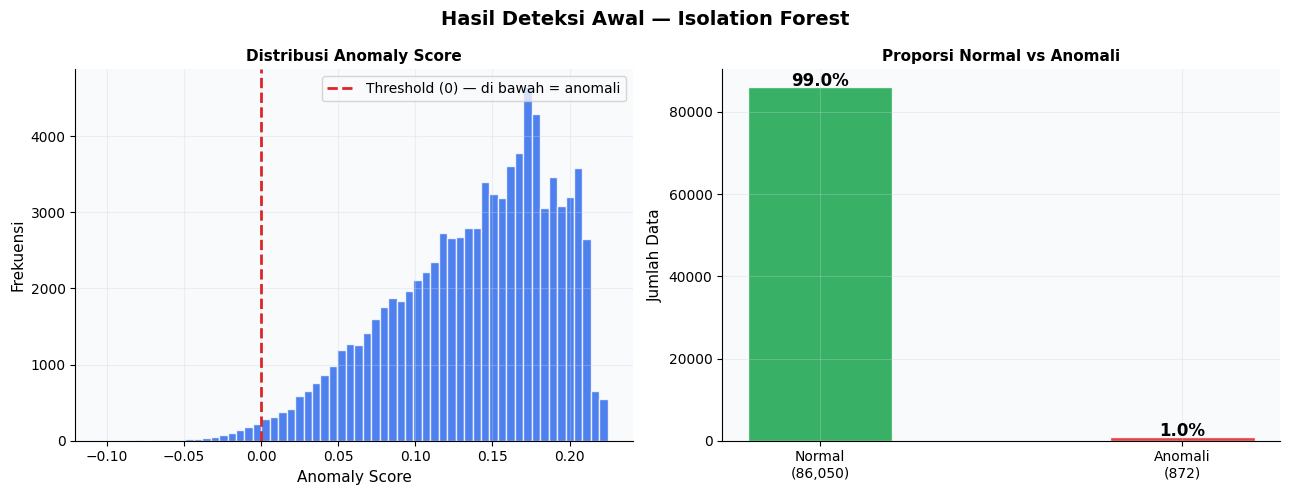

Gambar disimpan: preview_anomaly_detection.png


In [21]:
# Visualisasi anomaly score
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Hasil Deteksi Awal — Isolation Forest', fontsize=14, fontweight='bold')

# Distribusi anomaly score
axes[0].hist(anomaly_scores, bins=60, color=BLUE, alpha=0.8, edgecolor='white')
axes[0].axvline(0, color=RED, linestyle='--', linewidth=2,
                label='Threshold (0) — di bawah = anomali')
axes[0].set_xlabel('Anomaly Score', fontsize=11)
axes[0].set_ylabel('Frekuensi', fontsize=11)
axes[0].set_title('Distribusi Anomaly Score', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10)

# Proporsi normal vs anomali
counts = [n_normal, n_anomaly]
labels = [f'Normal\n({n_normal:,})', f'Anomali\n({n_anomaly:,})']
bars = axes[1].bar(labels, counts, color=[GREEN, RED], alpha=0.85,
                   edgecolor='white', width=0.4)
for bar, val in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val/len(y_pred)*100:.1f}%',
                 ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Jumlah Data', fontsize=11)
axes[1].set_title('Proporsi Normal vs Anomali', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('preview_anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gambar disimpan: preview_anomaly_detection.png')

In [ ]:
# contoh reservasi yang terdeteksi sebagai anomali
df_result = df_clean[numerical_features + categorical_features].copy()
df_result['anomaly_label'] = y_pred
df_result['anomaly_score'] = anomaly_scores

anomalies = df_result[df_result['anomaly_label'] == -1].sort_values('anomaly_score')

print(f'10 reservasi dengan anomaly score terendah (paling anomali):')
print(anomalies[['adr','lead_time','total_nights','total_guests',
                 'booking_changes','anomaly_score']].head(10).to_string())

10 reservasi dengan anomaly score terendah (paling anomali):
         adr  lead_time  total_nights  total_guests  booking_changes  anomaly_score
36554  270.0         33             3             2               10      -0.103856
79007    0.0          2             1             1                0      -0.091305
15266    7.0         26             3             1                1      -0.085984
15263    0.0         24            30             1                5      -0.081675
15296    0.0         31             2             2                3      -0.079894
14970    0.0        252             8             2                4      -0.078116
14910  211.2        192            10             3                2      -0.072741
15261    2.4          8             5             1                2      -0.069793
39557  310.0         33             3             4                8      -0.067892
81092    0.0          1             2             2                0      -0.066632


---
## 6. Simpan Dataset Bersih (dataset_clean.csv)

In [ ]:
df_clean_save = df_clean[numerical_features + categorical_features].copy()
df_clean_save.to_csv('dataset_clean.csv', index=False)

import os
size_mb = os.path.getsize('dataset_clean.csv') / (1024 * 1024)
print(f'dataset_clean.csv berhasil disimpan!')
print(f'Ukuran file : {size_mb:.2f} MB')
print(f'Shape       : {df_clean_save.shape}')

dataset_clean.csv berhasil disimpan!
Ukuran file : 7.25 MB
Shape       : (86922, 18)
